# Heart Disease Prediction — Decision Tree Classifier
### Exploratory Data Analysis & Model Building

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('../data/heart.csv')
print('Shape:', df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,2,126,458,1,2,154,1,5.4,2,0,2,1
1,57,0,0,158,384,0,1,76,0,1.0,0,3,3,1
2,43,0,3,111,286,0,2,201,1,4.9,1,3,2,1
3,71,1,2,189,515,1,1,71,1,3.6,0,0,1,1
4,36,0,0,142,303,0,2,128,1,3.5,0,3,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.00000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,52.267327,0.544554,1.40264,146.511551,352.894389,0.471947,0.976898,135.491749,0.524752,3.020462,0.973597,1.462046,2.039604,0.498350
std,13.896179,0.498835,1.16925,31.336124,127.705381,0.500038,0.827584,39.067937,0.500213,1.774351,0.801052,1.167033,0.840854,0.500824
min,29.000000,0.000000,0.00000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,40.000000,0.000000,0.00000,119.000000,245.500000,0.000000,0.000000,102.000000,0.000000,1.400000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.000000,1.00000,148.000000,354.000000,0.000000,1.000000,134.000000,1.000000,3.100000,1.000000,2.000000,2.000000,0.000000
75%,64.000000,1.000000,2.00000,174.000000,456.000000,1.000000,2.000000,168.500000,1.000000,4.600000,2.000000,3.000000,3.000000,1.000000
max,76.000000,1.000000,3.00000,199.000000,563.000000,1.000000,2.000000,201.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [5]:
print('Missing values:\n', df.isnull().sum())
print('\nTarget distribution:\n', df['target'].value_counts())

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target distribution:
 target
0    152
1    151
Name: count, dtype: int64


## 2. Exploratory Data Analysis

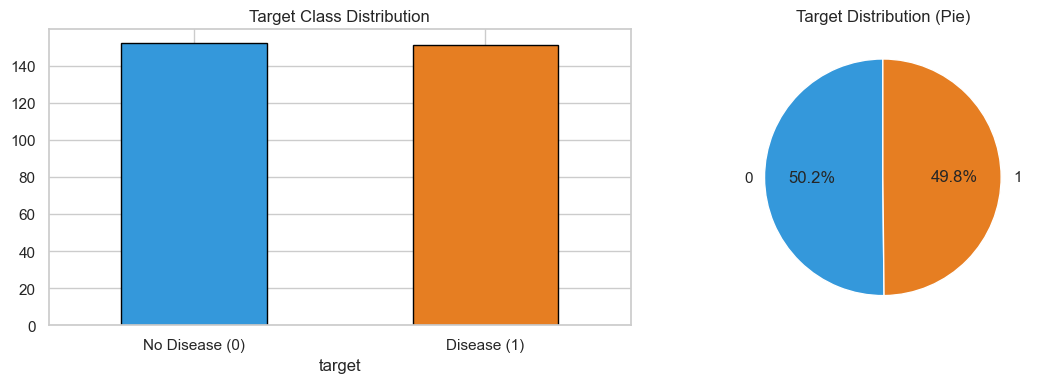

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db','#e67e22'], edgecolor='black')
axes[0].set_title('Target Class Distribution')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                  colors=['#3498db','#e67e22'], startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Target Distribution (Pie)')
plt.tight_layout()
plt.show()

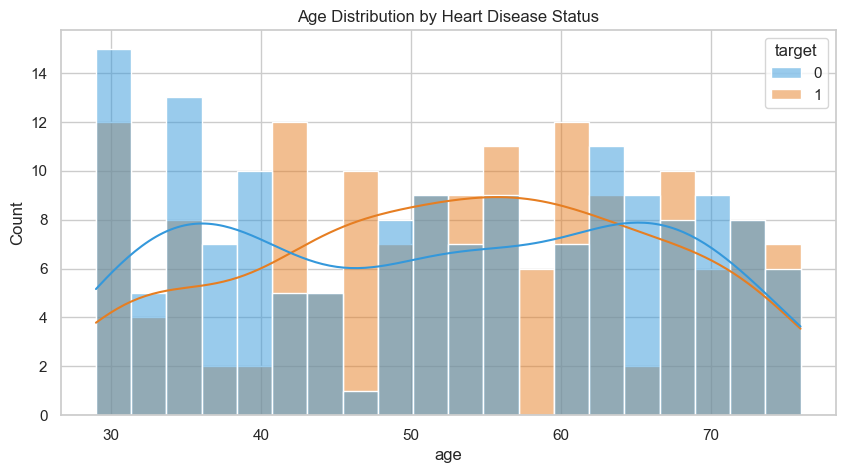

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', kde=True, bins=20, palette={0:'#3498db', 1:'#e67e22'})
plt.title('Age Distribution by Heart Disease Status')
plt.show()

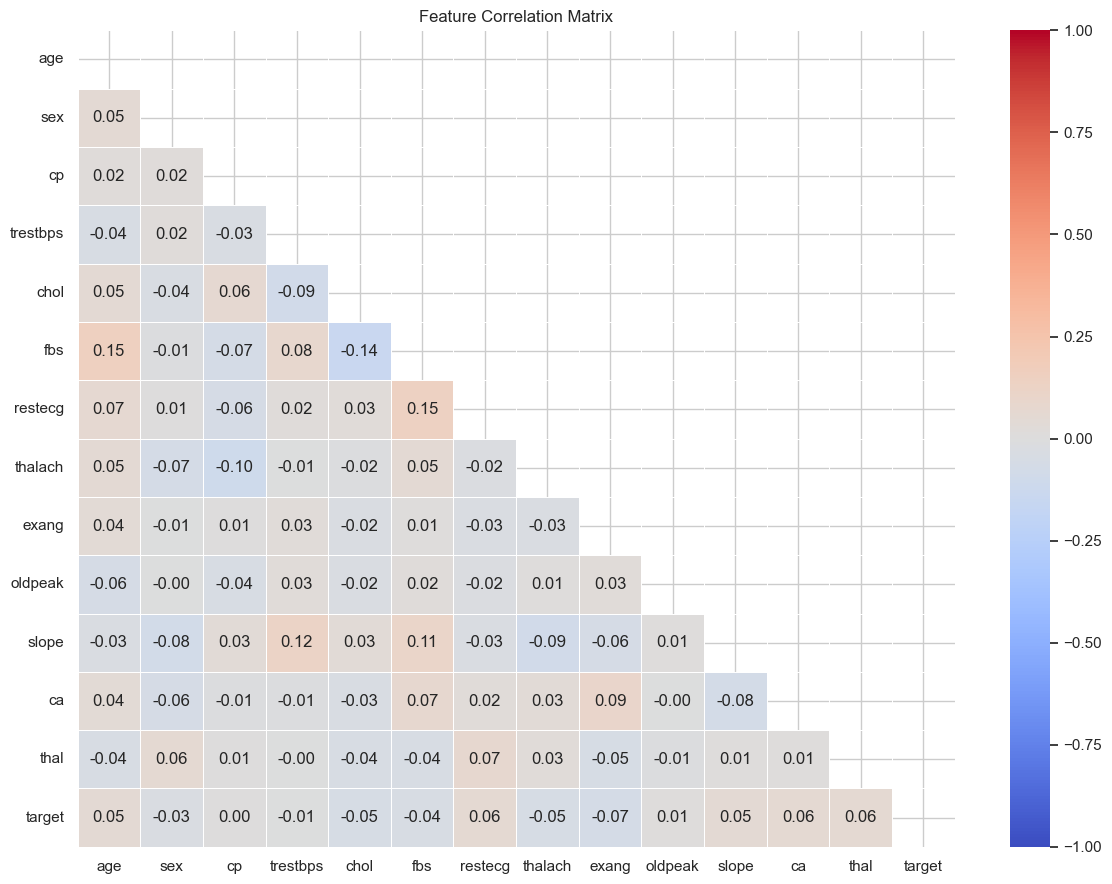

In [8]:
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

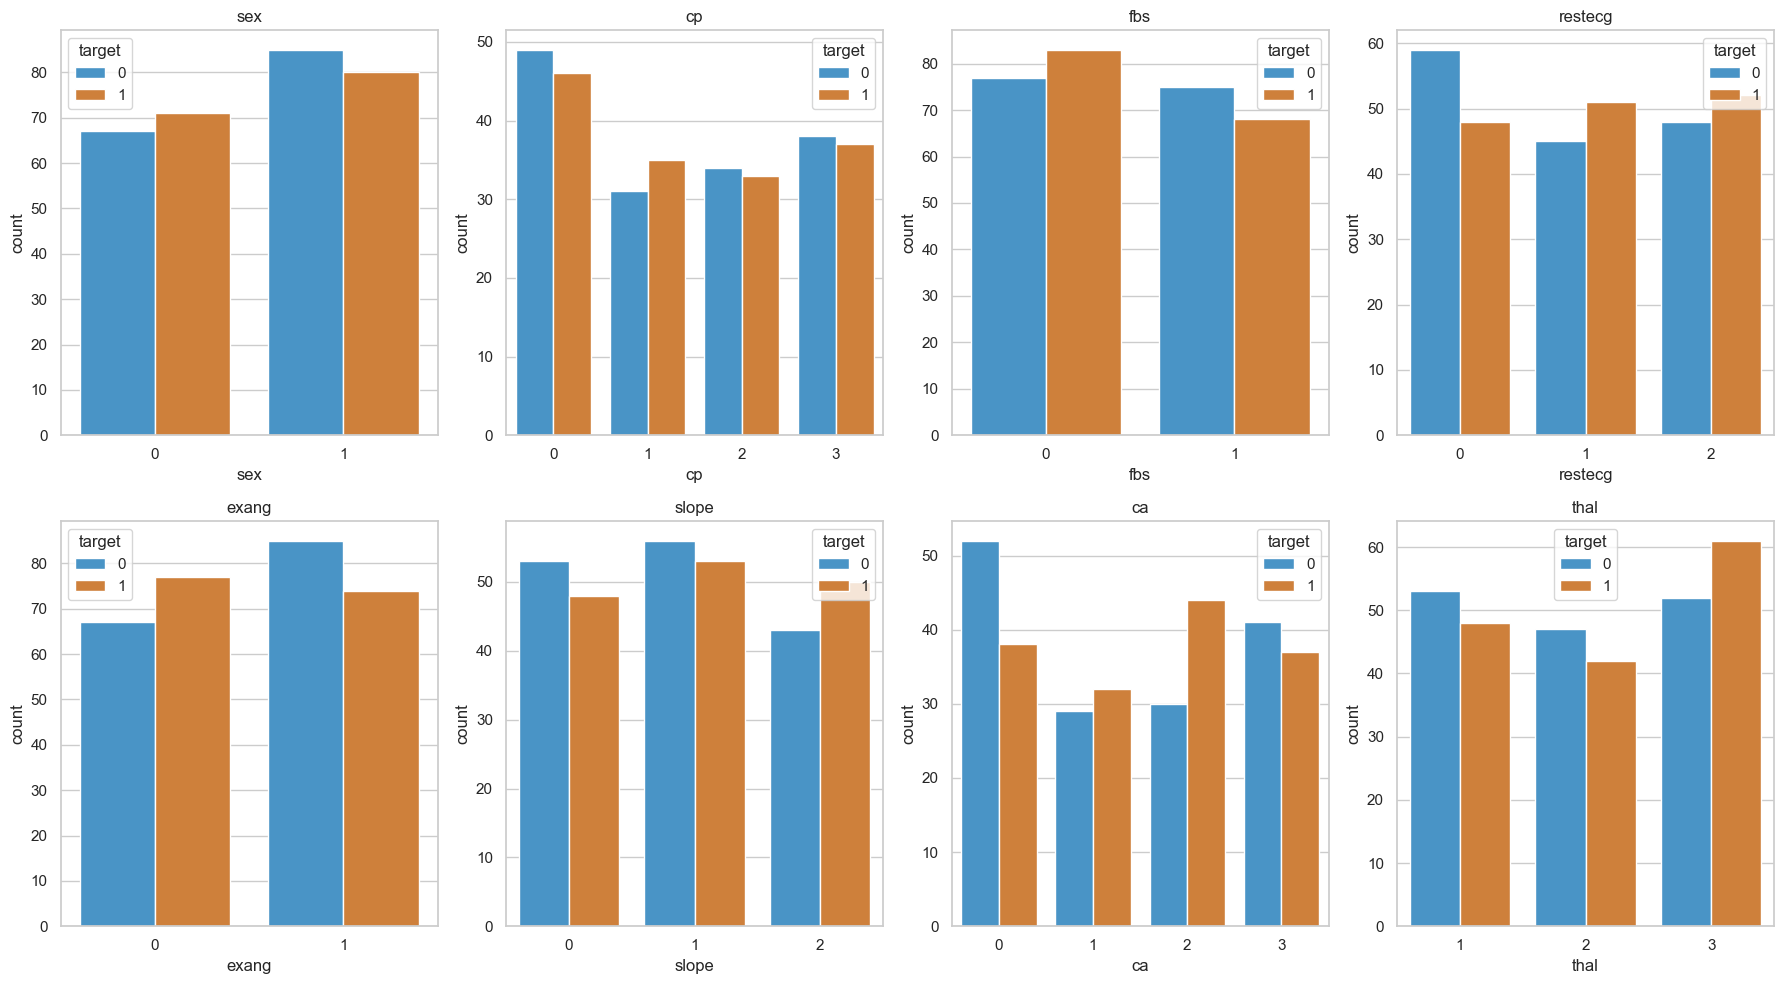

In [10]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for i, feat in enumerate(cat_features):
    row, col = divmod(i, 4)
    sns.countplot(data=df, x=feat, hue='target', ax=axes[row][col], palette={0:'#3498db', 1:'#e67e22'})
    axes[row][col].set_title(feat)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [11]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (242, 13)  |  Test: (61, 13)


## 4. Finding Optimal Tree Depth

Best Depth: 2  |  Best Test Accuracy: 0.4754


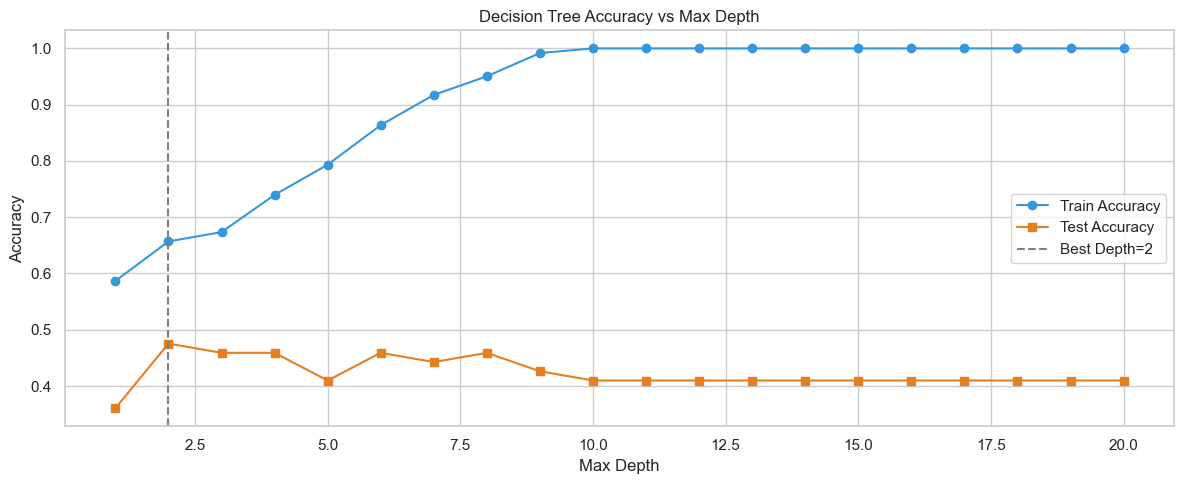

In [12]:
depths = range(1, 21)
train_acc, test_acc = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_sc, y_train)
    train_acc.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    test_acc.append(accuracy_score(y_test,  dt.predict(X_test_sc)))
best_depth = depths[np.argmax(test_acc)]
print(f'Best Depth: {best_depth}  |  Best Test Accuracy: {max(test_acc):.4f}')
plt.figure(figsize=(12, 5))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy', color='#3498db')
plt.plot(depths, test_acc,  marker='s', label='Test Accuracy',  color='#e67e22')
plt.axvline(best_depth, linestyle='--', color='gray', label=f'Best Depth={best_depth}')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Train Final Model & Evaluate

In [13]:
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred = dt.predict(X_test_sc)
y_prob = dt.predict_proba(X_test_sc)[:, 1]
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))

Accuracy : 0.4754
ROC-AUC  : 0.4043
              precision    recall  f1-score   support

  No Disease       0.49      0.55      0.52        31
     Disease       0.46      0.40      0.43        30

    accuracy                           0.48        61
   macro avg       0.47      0.47      0.47        61
weighted avg       0.47      0.48      0.47        61



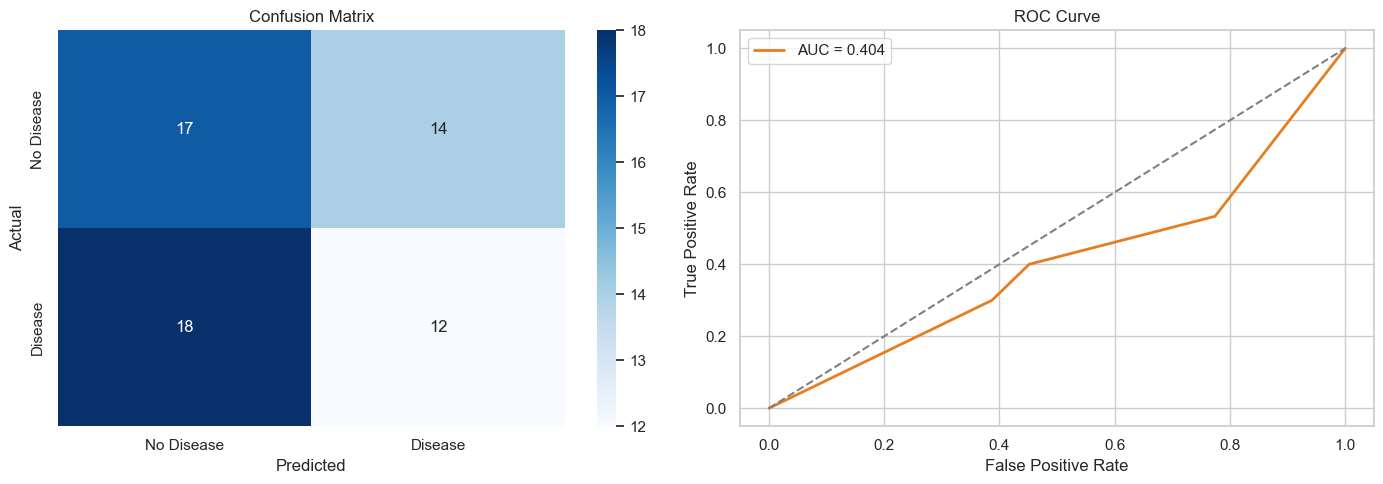

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e67e22', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1], 'gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.show()

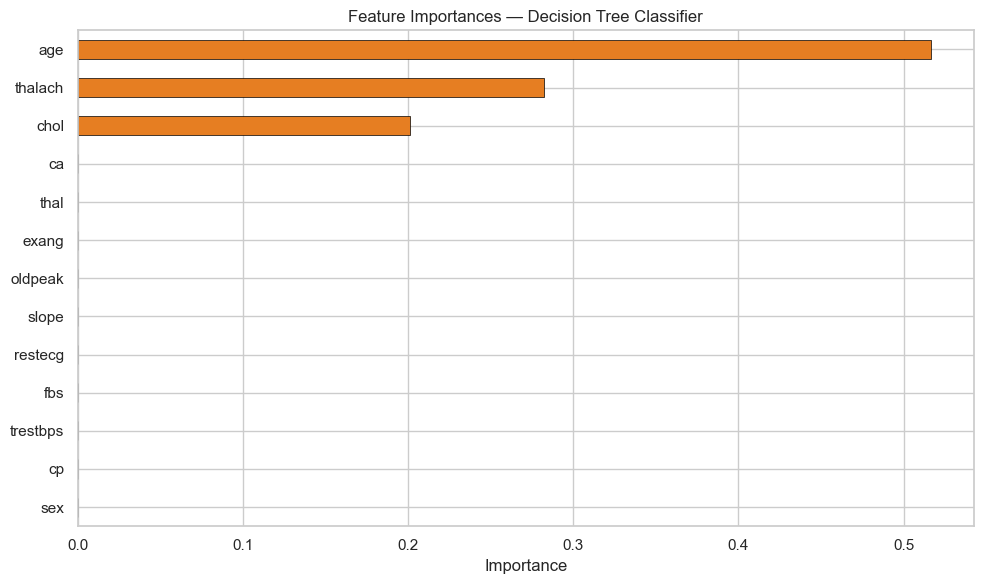

In [15]:
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#e67e22', edgecolor='black', linewidth=0.5)
plt.title('Feature Importances — Decision Tree Classifier')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

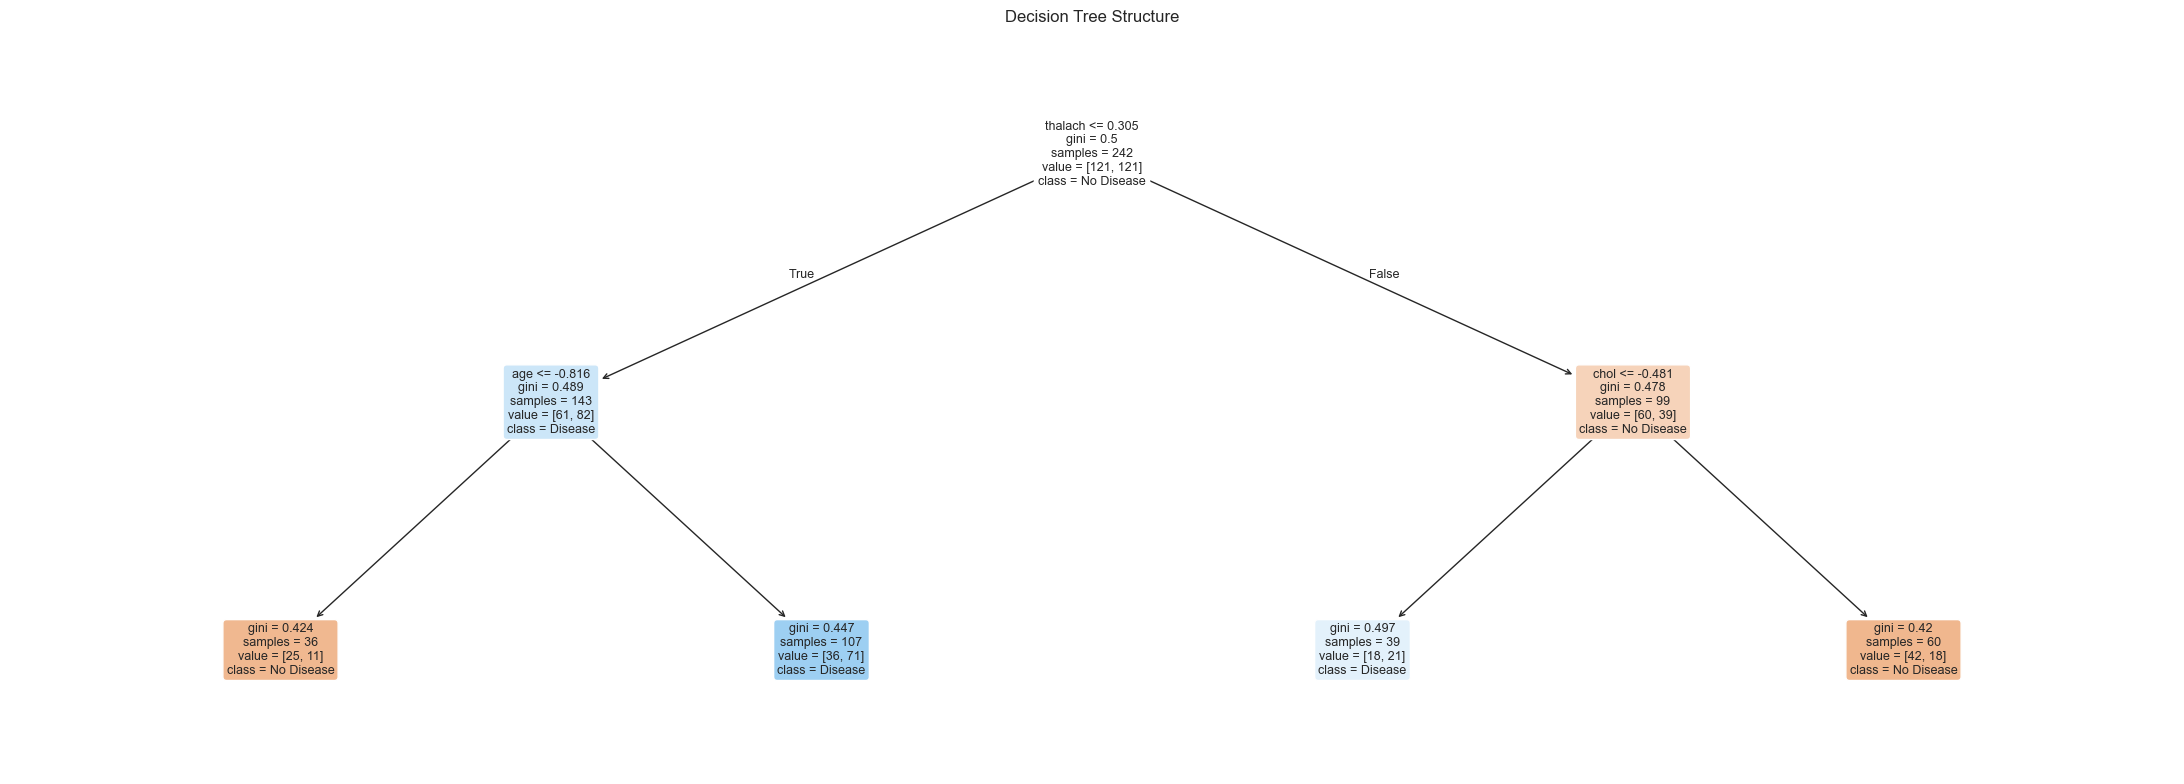

In [16]:
plt.figure(figsize=(22, 8))
plot_tree(dt, feature_names=X.columns.tolist(), class_names=['No Disease','Disease'],
          filled=True, rounded=True, fontsize=9, max_depth=3)
plt.title('Decision Tree Structure')
plt.tight_layout()
plt.show()

In [17]:
cv_scores = cross_val_score(dt, scaler.transform(X), y, cv=10, scoring='accuracy')
print(f'10-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

10-Fold CV Accuracy: 0.5908 ± 0.0642


## 6. Save Model & Scaler

In [18]:
joblib.dump(dt,     '../models/dt_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print('dt_model.pkl and scaler.pkl saved to models/')

dt_model.pkl and scaler.pkl saved to models/
